In [1]:
from tqdm import tqdm
from airbnb_images_scrapper import AirbnbImagesScrapping
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import numpy as np
from urllib.request import urlretrieve

import warnings, os
import mysql.connector as mysql
warnings.filterwarnings('ignore')
username = os.environ['MYSQL_user']
password = os.environ['MYSQL_password']
DB = mysql.connect(host = "localhost", user = username, passwd = password, database = "AIRBNB")
cursor = DB.cursor(buffered=True)

## Utils

In [2]:
def read_table_from_db(table_name):
    df = pd.read_sql(f'SELECT * FROM {table_name}', con=DB)
    return df

# Load dataset

In [3]:
table_name = "listings_eda"
listings = read_table_from_db(table_name)
listings

,listing_id,listing_url,host_is_superhost,host_has_profile_pic,host_identity_verified,accommodates,bedrooms,beds,minimum_nights,maximum_nights,...,review_scores_location_0_50,review_scores_location_51_80,review_scores_location_81_90,review_scores_location_91_95,review_scores_location_96_100,review_scores_value_0_50,review_scores_value_51_80,review_scores_value_81_90,review_scores_value_91_95,review_scores_value_96_100
0,2595,https://www.airbnb.com/rooms/2595,0,1,1,1.0,0.0,1.0,30.0,1125.0,...,0,0,0,0,1,0,0,1,0,0
1,5121,https://www.airbnb.com/rooms/5121,0,1,1,2.0,1.0,1.0,30.0,150.0,...,0,0,1,0,0,0,0,0,1,0
2,5136,https://www.airbnb.com/rooms/5136,0,1,1,4.0,2.0,2.0,30.0,730.0,...,0,0,0,1,0,0,0,0,1,0
3,6848,https://www.airbnb.com/rooms/6848,1,1,1,3.0,2.0,1.0,30.0,730.0,...,0,0,0,1,0,0,0,0,1,0
4,6872,https://www.airbnb.com/rooms/6872,0,1,1,1.0,1.0,1.0,30.0,180.0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32817,1237082867457012401,https://www.airbnb.com/rooms/1237082867457012401,0,1,1,2.0,1.0,1.0,30.0,365.0,...,0,0,0,0,0,0,0,0,0,0
32818,1237100764139053201,https://www.airbnb.com/rooms/1237100764139053201,0,1,1,8.0,3.0,3.0,30.0,365.0,...,0,0,0,0,0,0,0,0,0,0
32819,1237358247584723886,https://www.airbnb.com/rooms/1237358247584723886,1,1,1,1.0,1.0,1.0,30.0,190.0,...,0,0,0,0,0,0,0,0,0,0
32820,1237635858712477126,https://www.airbnb.com/rooms/1237635858712477126,0,0,1,1.0,1.0,1.0,30.0,365.0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
table_name = "images"
images_data = read_table_from_db(table_name)
images_data

,listing_id,listing_url,image_url,image,room_type,id,is_predicted
0,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/5401233b-a...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,1,0
1,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,2,0
2,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,3,1
3,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,4,1
4,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,5,1
...,...,...,...,...,...,...,...
382475,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bathroom,384120,1
382476,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384121,1
382477,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384122,1
382478,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384123,1


# Scraping images

Initialize AirbnbImagesScrapping instance which will be used to scrape images out of provided listings URLs.

In [5]:
TEMP_FILE = 'temp.png'
def _get_blob(image_url):
    try:
        urlretrieve(image_url, TEMP_FILE)
        with open(TEMP_FILE, 'rb') as f:
            image_data = f.read()
    except:
        image_data = None
    return image_data

airbnb_scrapper = AirbnbImagesScrapping()

## Listings without images

Get those listings which do not have images in `images_data`.

It means that they were not scraped yet.

In [6]:
listings_without_images = listings[~listings['listing_id'].isin(images_data['listing_id'])]
listings_without_images

,listing_id,listing_url,host_is_superhost,host_has_profile_pic,host_identity_verified,accommodates,bedrooms,beds,minimum_nights,maximum_nights,...,review_scores_location_0_50,review_scores_location_51_80,review_scores_location_81_90,review_scores_location_91_95,review_scores_location_96_100,review_scores_value_0_50,review_scores_value_51_80,review_scores_value_81_90,review_scores_value_91_95,review_scores_value_96_100


In [8]:
column_names = ', '.join([column for column in images_data.columns if column != 'id'])
values_string = ', '.join(['%s' for _ in range(len(images_data.columns)-1)])
insert_script = f"INSERT INTO {table_name} ({column_names}) VALUES ({values_string})"
for i in tqdm(range(len(listings_without_images))):
    listing_id = int(listings_without_images.iloc[i]['listing_id'])
    listing_url = listings_without_images.iloc[i]['listing_url']
    results = airbnb_scrapper.run(listing_url)
    if type(results) == str:
        values = (listing_id, listing_url, results, None, None)
        cursor.execute(insert_script, values)
        DB.commit()
    else:
        values = []
        for image_url, room_type in zip(results["images"], results["room_types"]):
            image = _get_blob(image_url)
            values.append((listing_id, listing_url, image_url, image, room_type))
        cursor.executemany(insert_script, values)
        DB.commit()

100%|██████████| 5/5 [01:32<00:00, 18.46s/it]


## Failed to scrape

Due to some problems during scraping some of the listings were not scraped properly (e.g. due to connection problems).

This part of the code will retry to scrape those listings.

In [9]:
failed_images = images_data[images_data['image_url'] == "Failed to scrape images"]
failed_images = failed_images.drop_duplicates(subset=['listing_id'])
failed_images

,listing_id,listing_url,image_url,image,room_type,id


In [10]:
column_names = ', '.join([column for column in images_data.columns if column != 'id'])
values_string = ', '.join(['%s' for _ in range(len(images_data.columns)-1)])
insert_script = f"INSERT INTO {table_name} ({column_names}) VALUES ({values_string})"
for i in tqdm(range(len(failed_images))):
    listing_id = int(failed_images.iloc[i]['listing_id'])
    listing_url = failed_images.iloc[i]['listing_url']
    results = airbnb_scrapper.run(listing_url)
    if results == "Failed to scrape images":
        continue
    elif results == "URL not found":
        cursor.execute(f"DELETE FROM {table_name} WHERE listing_id = {listing_id}")
        DB.commit()
        values = (listing_id, listing_url, results, None, None)
        cursor.execute(insert_script, values)
        DB.commit()
    else:
        #Remove the row from the database
        cursor.execute(f"DELETE FROM {table_name} WHERE listing_id = {listing_id}")
        DB.commit()
        #Add the new images
        values = []
        for image_url, room_type in zip(results["images"], results["room_types"]):
            image = _get_blob(image_url)
            values.append((listing_id, listing_url, image_url, image, room_type))
        cursor.executemany(insert_script, values)
        DB.commit()

0it [00:00, ?it/s]


## URL not found

URL Not Found was saved in images_data mostly when listing_url was not found.

There is a slight possibility that the listing was removed from the website but now it is available again.

This part of the code will retry to scrape those listings.

In [11]:
not_found_images = images_data[images_data['image_url'] == "URL not found"]
not_found_images = not_found_images.drop_duplicates(subset=['listing_id'])
not_found_images

,listing_id,listing_url,image_url,image,room_type,id
1904,29683,https://www.airbnb.com/rooms/29683,URL not found,None,Unknown,1951
1975,34760,https://www.airbnb.com/rooms/34760,URL not found,None,Unknown,2022
2111,42882,https://www.airbnb.com/rooms/42882,URL not found,None,Unknown,2158
2150,45556,https://www.airbnb.com/rooms/45556,URL not found,None,Unknown,2197
2534,60164,https://www.airbnb.com/rooms/60164,URL not found,None,Unknown,2581
...,...,...,...,...,...,...
379028,47493612,https://www.airbnb.com/rooms/47493612,URL not found,None,Unknown,380643
379029,47497466,https://www.airbnb.com/rooms/47497466,URL not found,None,Unknown,380644
379030,47527528,https://www.airbnb.com/rooms/47527528,URL not found,None,Unknown,380645
379031,47533931,https://www.airbnb.com/rooms/47533931,URL not found,None,Unknown,380646


In [ ]:
column_names = ', '.join([column for column in images_data.columns if column != 'id'])
values_string = ', '.join(['%s' for _ in range(len(images_data.columns)-1)])
insert_script = f"INSERT INTO {table_name} ({column_names}) VALUES ({values_string})"
for i in tqdm(range(len(not_found_images))):
    listing_id = int(not_found_images.iloc[i]['listing_id'])
    listing_url = not_found_images.iloc[i]['listing_url']
    results = airbnb_scrapper.run(listing_url)
    if results == "URL not found":
        continue
    elif results == "Failed to scrape images":
        cursor.execute(f"DELETE FROM {table_name} WHERE listing_id = {listing_id}")
        DB.commit()
        values = (listing_id, listing_url, results, None, None)
        cursor.execute(insert_script, values)
        DB.commit()
    else:
        #Remove the row from the database
        cursor.execute(f"DELETE FROM {table_name} WHERE listing_id = {listing_id}")
        DB.commit()
        #Add the new images
        values = []
        for image_url, room_type in zip(results["images"], results["room_types"]):
            image = _get_blob(image_url)
            values.append((listing_id, listing_url, image_url, image, room_type))
        cursor.executemany(insert_script, values)
        DB.commit()
        print(results)

  0%|          | 16/13294 [00:38<36:39:48,  9.94s/it]

{'images': ['https://a0.muscache.com/im/pictures/c65b2ff9-edc5-47c0-b4d8-da9febf72888.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/30279516/194cf57b_original.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/06ead5cc-407a-4357-b838-19f3c6ee736f.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/ccc4409b-5cf9-4382-8b59-8912e2f6c953.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/fd7b6fe0-bc8e-4ccc-a26e-a5e5da5305e4.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/5184e1f6-d93d-4f82-bacf-36dc10ca5273.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/e627437f-d605-49a5-b409-aa473954f143.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/ab0d4918-9615-42ce-ad73-3f9ac1c7fbb3.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/a2e8c18f-175f-4bf0-82c7-28abdc42eac4.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/d289e515-48d3-4692-a568-9

  0%|          | 54/13294 [01:09<11:10:44,  3.04s/it]

{'images': ['https://a0.muscache.com/im/pictures/3683a3bb-f32f-444c-9a3e-fc27d9486ed5.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/17ded0d7-cb58-44e3-b74c-7a8723cef500.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/80987330-9afe-46b3-8733-90ef15153cd5.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/d8b381c2-b370-4460-98ab-d4cf3c89630b.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/8dc7c971-ba2e-4958-a088-39c7a271a9da.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/f897740d-bc56-437b-9a4d-b0aace9b7aad.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/4c14c161-6cfc-4eb4-a953-58ef8f32a49b.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/5422c74d-c96c-4606-a43c-6eb84a3d43df.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/9b451ec1-489e-45bf-8b1d-474ed7345267.jpg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/8091be18-ee73-4

  0%|          | 58/13294 [02:04<62:08:20, 16.90s/it]

...

 99%|█████████▉| 13205/13294 [3:09:00<06:12,  4.18s/it]

{'images': ['https://a0.muscache.com/im/pictures/prohost-api/Hosting-847662892666242208/original/51fdf6ab-d443-4b9a-b833-7229dfe839af.jpeg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/prohost-api/Hosting-847662892666242208/original/e63fa7a1-2f9f-4465-9b6b-113a2142747b.jpeg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/prohost-api/Hosting-847662892666242208/original/105c8e03-9b68-4c34-bec9-b7514d7776b3.jpeg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/prohost-api/Hosting-847662892666242208/original/35e3f793-9dc0-4c6e-b65b-658494460155.jpeg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/prohost-api/Hosting-847662892666242208/original/a75f2b4c-ca00-4276-8fd2-6649021cac9a.jpeg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/prohost-api/Hosting-847662892666242208/original/f024ab27-eff0-483f-8d5a-bd38645af2cd.jpeg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/prohost-api/Hosting-8476628926662

 99%|█████████▉| 13208/13294 [3:09:13<07:23,  5.16s/it]

{'images': ['https://a0.muscache.com/im/pictures/prohost-api/Hosting-863724752808681692/original/8bea884a-3076-41f7-9d48-af3d51808918.jpeg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/prohost-api/Hosting-863724752808681692/original/f3cd9bdc-494b-4dbd-a27c-a4b82c3f6408.jpeg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/prohost-api/Hosting-863724752808681692/original/cf0ff951-01d3-40f7-ace2-3e86bce8312f.jpeg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/prohost-api/Hosting-863724752808681692/original/dda01b0e-5701-426b-8b7a-34ee8419fa5d.jpeg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/prohost-api/Hosting-863724752808681692/original/fad7c79c-7c9c-497d-a0b6-414f87ddc892.jpeg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/prohost-api/Hosting-863724752808681692/original/f894ce1d-bf97-4aa0-afa7-2221835397c9.jpeg?im_w=720&im_format=avif', 'https://a0.muscache.com/im/pictures/prohost-api/Hosting-8637247528086

100%|██████████| 13294/13294 [3:10:05<00:00,  1.17it/s]


# Room type assignment

After scraping images and information about them it is time to assign room_types for those images which contained the "title" information.

There will be seven categories: `bedroom`, `kitcken`, `living_room`, `bathroom`, `dining_room`, `urban_environment`, `outside_building`.

Because currently room_type have a lot of unique values such as: "Zdjęcie kuchni", "Statua Wolności", "Podwórko" etc. 

I will go through most frequent of them and try to assing some of them to proper categories mentioned above.

For rest of them I will assign `Unknown` category.

In [ ]:
def change_room_type_in_db(word, class_name):
    for index, row in images_data.iterrows():
        if word.lower() in row['room_type'].lower():
            images_data.at[index, 'room_type'] = class_name
            cursor.execute(f"UPDATE images SET room_type = '{class_name}' WHERE id = {row['id']}")
            DB.commit()

word = "Zdjęcie oferty"
class_name = "Unknown"
# word = "Sypialni"
# class_name = "bedroom"
# word = "Kuchni"
# class_name = "kitchen"
# word = "Łazienk"
# class_name = "bathroom"
# word = "Salon"
# class_name = "living_room"
# word = "Jadalni"
# class_name = "dining_room"
# word = "Podwórko"
# class_name = "outside_building"
change_room_type_in_db(word, class_name)

In [18]:
print(images_data['room_type'].value_counts(ascending=False).to_dict())

{'Unknown': 255989, 'bedroom': 38426, 'bathroom': 29832, 'kitchen': 15885, 'outside_building': 14230, 'living_room': 13360, 'urban_environment': 8277, 'dining_room': 6481}


In [ ]:
#Before transforming room_type which I was unable to categorize (e.g. "Zdjęcie oferty 1" or "Udogodnienie nieruchomości") to "Unknown"
#Below I saved number of listings which have images entitled by their hosts.
# num_listings_without_unknown = images_data.groupby('listing_id').filter(lambda x: all(x['room_type'] != 'Unknown'))["listing_id"].nunique()
# print(f"Number of unique listing_id with all room types != Unknown: {num_listings_without_unknown}") # 7726 


#W pracy napisałbym, że te 7726 listingów miało przypisane informacje przez hostów, i próbowałem je jakoś skategoryzować bazując na nazwach, ale nie byłem w stanie tego zrobić w przypadku wszystkich obrazów, takich jak: "Zdjęcie oferty 1", ..., ponieważ były zbyt mało informatywne i ciężkie do jednoznacznej klasyfikacji bez weryfikacji i spojrzenia wcześniej na zdjęcie.

#Napisać później ile finalnie udało się skategoryzować i wstawić wykres rozkładu liczby zdjęć per kategoria.

In [ ]:
def change_room_type_to_unknown():
    for index, row in images_data.iterrows():
        if row['room_type'] not in ["bedroom", "kitchen", "bathroom", "living_room", "dining_room", "outside_building", "urban_environment"]:
            images_data.at[index, 'room_type'] = "Unknown"
            cursor.execute(f"UPDATE images SET room_type = 'Unknown' WHERE id = {row['id']}")
            DB.commit()
# change_room_type_to_unknown()

Now after assigning `room_type` to images I will use these information to train my computer vision classifier.

After training the model I will use it to predict room_type for the rest of the images.

Model training, data preparation and evaluation was done in `Room_Classifier` folder.

# Automated room type assignment

We will leverage the trained model to predict room types for the images with `room_type` equal to `Unknown`.

After some investigation it was decided to use threshold equal to 0.5 and if the prediction will not exceed it then there will be a category "other" assigned."

In [5]:
from Room_Classifier.inference_utils.room_classifier_model import RoomTypeClassification

onnx_model_path: str = "./Room_Classifier/Models/resnet18_07_03/best.onnx"
num_threads: int = 3
smallest_max_size: int = 256
image_resolution: tuple[int, int] = (224, 224)
mean: list[float] = [0.6032591, 0.56755817, 0.5286094]
std: list[float] = [0.20900008, 0.2107773, 0.21879801]

room_type_model = RoomTypeClassification(
    model_path=onnx_model_path,
    model_threads=num_threads,
    smallest_max_size=smallest_max_size,
    image_resolution=image_resolution,
    mean=mean,
    std=std,
)

THRESHOLD: float = 0.5

In [6]:
def bytes_to_image(bytes_image: bytes) -> np.ndarray:
    """
    Function that converts bytes to an image.
    
    Args:
        bytes_image (bytes): Bytes of the image.
    
    Returns:
        np.ndarray: Image.
    """
    image = cv2.imdecode(np.frombuffer(bytes_image, np.uint8), cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

def get_class_image(image: np.ndarray, threshold: float = 0.5) -> tuple[str, float]:
    """
    Function that takes an image in bytes format and returns the predicted room type.
    
    Args:
        image (np.ndarray): image as np.ndarray.
        threshold (float): Threshold for the prediction probability. Defaults to 0.5.
    
    Returns:
        tuple[str, float]: 
            - Predicted room type or "other" if the probability is below the threshold.
            - Probability of the prediction.
    """
    prediction = room_type_model.predict(image)
    prob = prediction["probability"]
    if prob >= threshold:
        return prediction["room_type"], prob
    return "other", prob

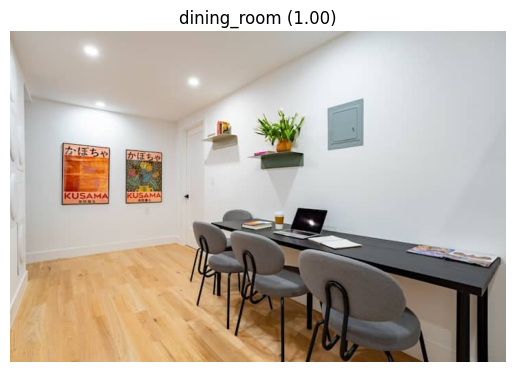

In [7]:
random_bytes_image = images_data.sample(1)["image"].values[0]
random_image = bytes_to_image(random_bytes_image)
prediction, prob = get_class_image(random_image)
plt.title(f"{prediction} ({prob:.2f})")
plt.imshow(random_image)
plt.axis("off")
plt.show()

In [8]:
with tqdm(
        total=len(images_data),
        unit="images",
        unit_scale=True,
        desc=f"Processing images",
    ) as pbar:
    for index, row in images_data.iterrows():
        if row['room_type'] == "Unknown":
            bytes_image = row["image"]
            if not bytes_image:
                pbar.update(1)
                continue
            image = bytes_to_image(bytes_image)
            prediction, prob = get_class_image(image)
            cursor.execute(f"UPDATE images SET room_type = '{prediction}', is_predicted = TRUE WHERE id = {row['id']}")
            DB.commit()
        pbar.update(1)

Processing images: 100%|██████████| 382k/382k [00:04<00:00, 80.5kimages/s]  
